In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
sns.set_style('whitegrid')

In [4]:
df = pd.read_csv('../../datasets/german_credit_data.csv')

In [5]:
df.head(5)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [6]:
df.describe(include='all')

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.500000,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,249.750000,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,499.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,749.250000,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [8]:
df['Saving accounts'].isnull().sum()

np.int64(183)

In [9]:
df['Checking account'].isnull().sum()

np.int64(394)

In [10]:
df.dropna(inplace=True)

In [11]:
df.shape

(522, 11)

In [12]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [13]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [14]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
7,35,male,3,rent,little,moderate,6948,36,car,good
9,28,male,3,own,little,moderate,5234,30,car,bad


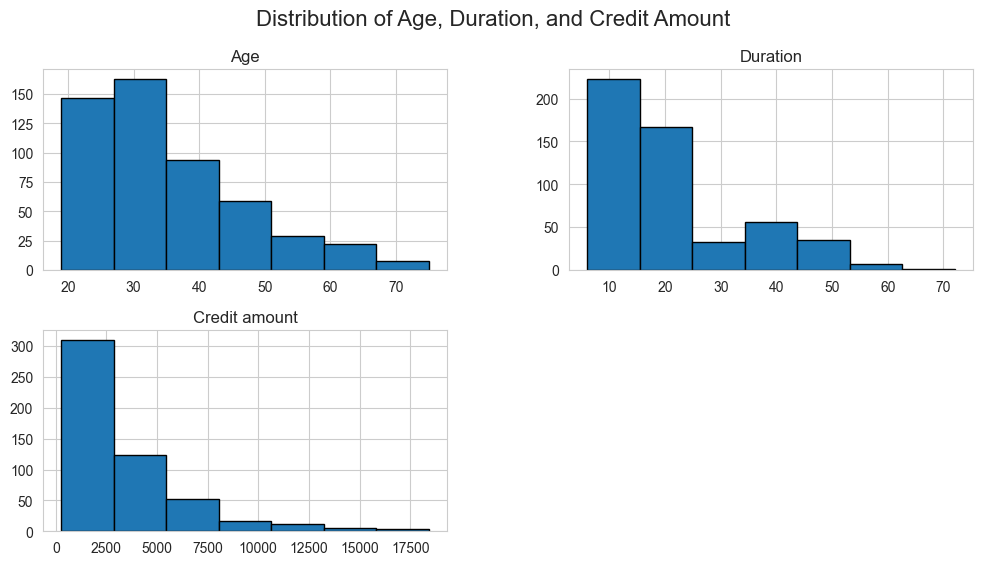

In [15]:
df[['Age', 'Duration', 'Credit amount']].hist(bins=7, edgecolor='black', figsize=(12, 6))
plt.suptitle('Distribution of Age, Duration, and Credit Amount', fontsize=16)
plt.show()

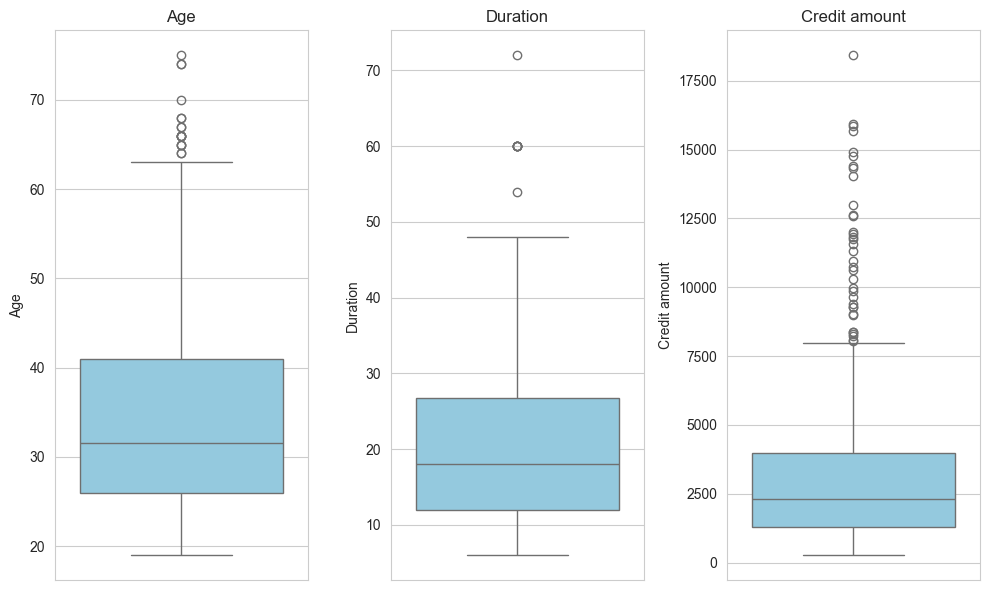

In [16]:
plt.figure(figsize=(10, 6))
for i, col in enumerate(['Age', 'Duration', 'Credit amount']):
    plt.subplot(1,3,i+1)
    sns.boxplot(y = df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

In [17]:
df.query('Duration > 70')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [18]:
df.query('Duration >= 60')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,63,male,2,own,little,little,6836,60,business,bad
332,24,female,3,own,moderate,moderate,7408,60,car,bad
374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
714,27,male,3,own,little,moderate,14027,60,car,bad
938,42,male,2,free,little,moderate,6288,60,education,bad
973,36,male,2,rent,little,little,7297,60,business,bad


In [19]:
cat_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

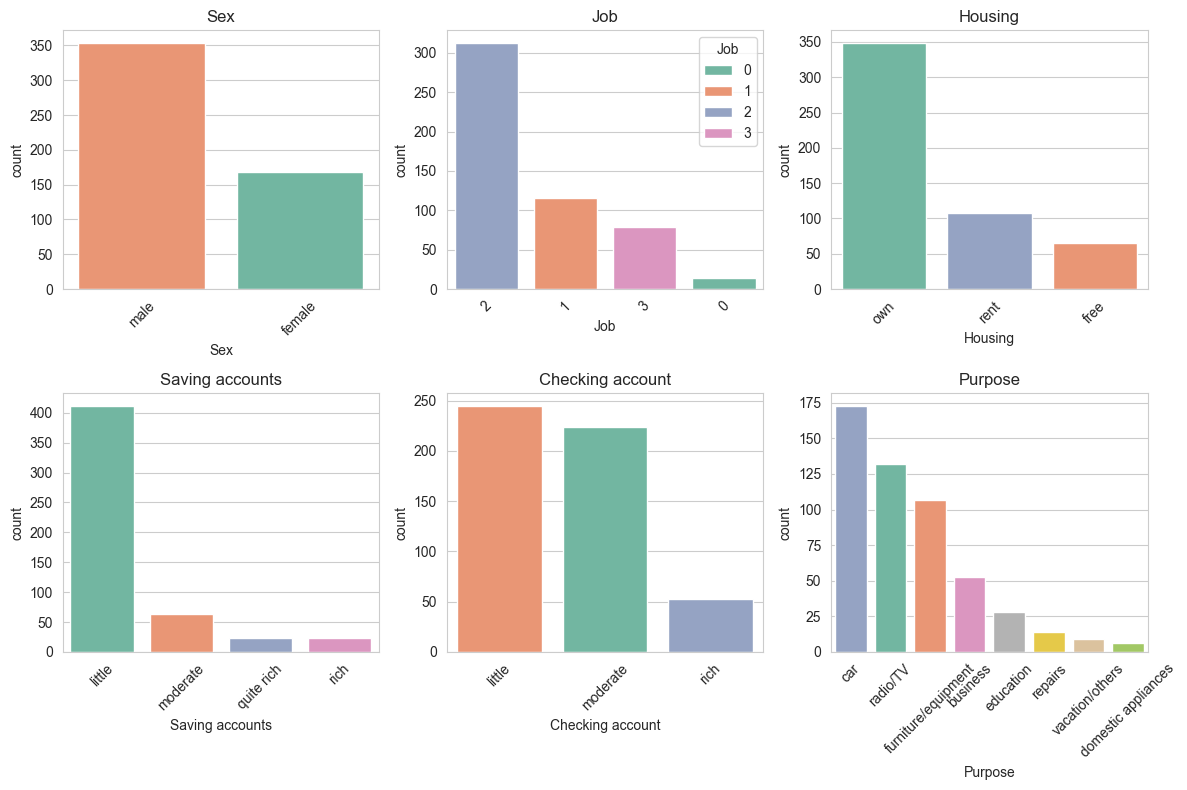

In [20]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x = col, data = df,hue=col, palette="Set2", order = df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

In [21]:
corr = df[['Age', 'Job', 'Duration', 'Credit amount']].corr()

In [22]:
corr

,Age,Job,Duration,Credit amount
Age,1.000000,0.039771,0.001549,0.082014
Job,0.039771,1.000000,0.200794,0.334721
Duration,0.001549,0.200794,1.000000,0.613298
Credit amount,0.082014,0.334721,0.613298,1.000000


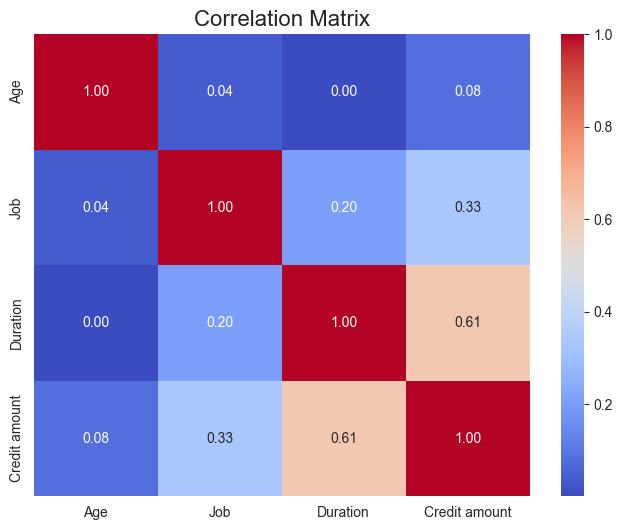

In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix', fontsize=16)
plt.show()

In [24]:
df.groupby('Job')['Credit amount'].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [25]:
df.groupby('Sex')['Credit amount'].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [26]:
pd.pivot_table(df, index='Housing', columns='Purpose', values='Credit amount', aggfunc='mean')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


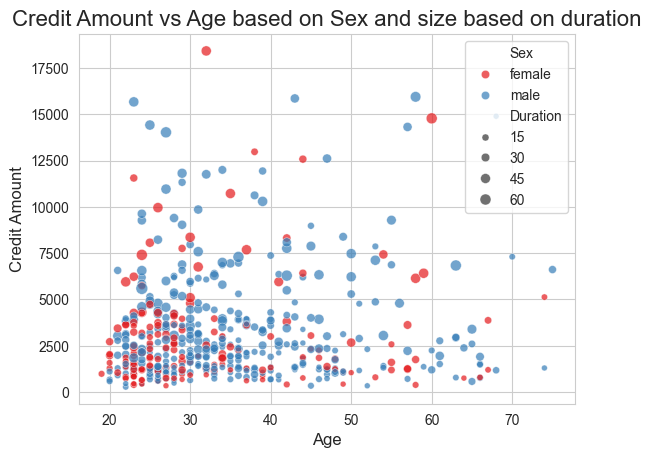

In [27]:
sns.scatterplot(x='Age', y='Credit amount', data=df, hue='Sex', size='Duration', palette='Set1', alpha=0.7)
plt.title('Credit Amount vs Age based on Sex and size based on duration', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Credit Amount', fontsize=12)
plt.show()

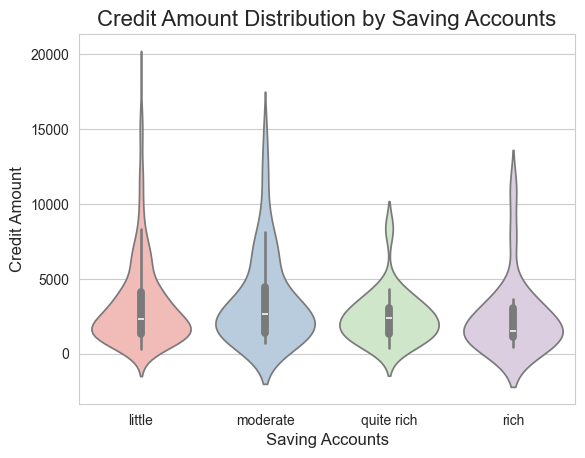

In [28]:
sns.violinplot(data = df, x = 'Saving accounts', y = 'Credit amount',hue='Saving accounts',  palette = 'Pastel1')
plt.title('Credit Amount Distribution by Saving Accounts', fontsize=16)
plt.xlabel('Saving Accounts', fontsize=12)
plt.ylabel('Credit Amount', fontsize=12)
plt.show()

In [29]:
df['Risk'].value_counts(normalize=True)*100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

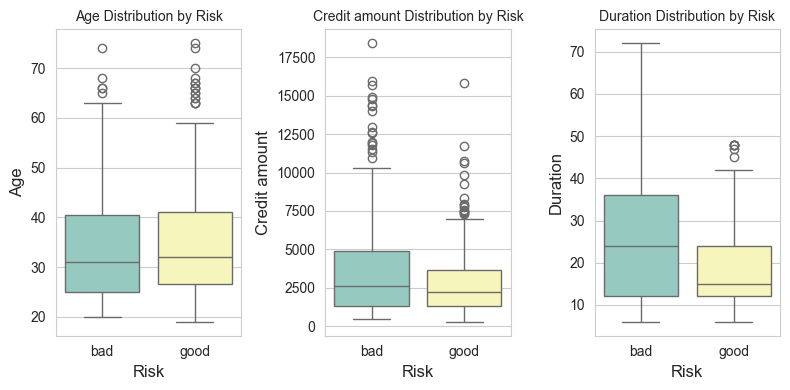

In [30]:
plt.figure(figsize=(8, 4))
for i,col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1,3,i+1)
    sns.boxplot(x='Risk', y=col, data=df, hue= 'Risk', palette='Set3')
    plt.title(f'{col} Distribution by Risk', fontsize=10)
    plt.xlabel('Risk', fontsize=12)
    plt.ylabel(col, fontsize=12)
plt.tight_layout()    
plt.show()

In [31]:
df.groupby('Risk')[['Age', 'Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


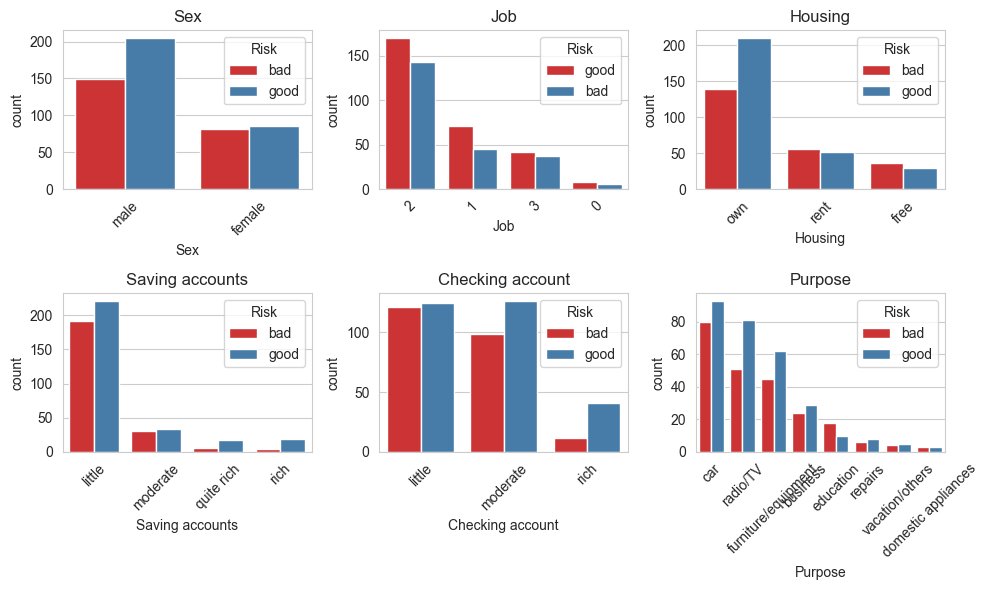

In [32]:
plt.figure(figsize=(10, 6))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x = col, data = df,hue='Risk', palette="Set1", order = df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

In [33]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [34]:
features = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration']

In [35]:
target = 'Risk'

In [36]:
df_model = df[features + [target]].copy()

In [37]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
1,22,female,2,own,little,moderate,5951,48,bad
3,45,male,2,free,little,little,7882,42,good
4,53,male,2,free,little,little,4870,24,bad
7,35,male,3,rent,little,moderate,6948,36,good
9,28,male,3,own,little,moderate,5234,30,bad


In [38]:
# encoding categorical variables
from sklearn.preprocessing import LabelEncoder
import joblib

In [40]:
catCols = df_model.select_dtypes(include='str').columns.drop('Risk')

In [41]:
le_dict = {}

In [42]:
for col in catCols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_encoder.pkl")

In [43]:
le_target = LabelEncoder()

In [44]:
df_model[target] = le_target.fit_transform(df_model[target])

In [47]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [48]:
joblib.dump(le_target, 'target_encoder.pkl')

['target_encoder.pkl']

In [49]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
1,22,0,2,1,0,1,5951,48,0
3,45,1,2,0,0,0,7882,42,1
4,53,1,2,0,0,0,4870,24,0
7,35,1,3,2,0,1,6948,36,1
9,28,1,3,1,0,1,5234,30,0


In [51]:
X = df_model.drop(columns='Risk')

In [55]:
y = df_model[target]

In [53]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
1,22,0,2,1,0,1,5951,48
3,45,1,2,0,0,0,7882,42
4,53,1,2,0,0,0,4870,24
7,35,1,3,2,0,1,6948,36
9,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
989,48,1,1,1,0,1,1743,24
993,30,1,3,1,0,0,3959,36
996,40,1,3,1,0,0,3857,30
998,23,1,2,0,0,0,1845,45


In [56]:
y

1      0
3      1
4      0
7      1
9      0
      ..
989    1
993    1
996    1
998    0
999    1
Name: Risk, Length: 522, dtype: int64

In [50]:
from sklearn.model_selection import train_test_split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y,random_state=1)

In [60]:
X_train.shape

(417, 8)

In [61]:
X_test.shape

(105, 8)

In [ ]:
# model training
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [65]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [66]:
dt = DecisionTreeClassifier(random_state=1, class_weight='balanced')
dt_param = {
    "max_depth" : [3,5,7,10, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [67]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param, X_train, y_train, X_test, y_test)

In [68]:
print(acc_dt)

0.580952380952381


In [69]:
print(params_dt)

{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [70]:
rf = RandomForestClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [73]:
rf_params = {
    "n_estimators": [100,200],
    "max_depth": [5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [74]:
best_rf, acc_rf, params_rf = train_model(rf, rf_params, X_train, y_train, X_test, y_test)

In [75]:
print(acc_rf)

0.6190476190476191


In [76]:
print(params_rf)

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [77]:
print(best_rf)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       min_samples_split=10, n_jobs=-1, random_state=1)


In [88]:
et = ExtraTreesClassifier(random_state=1, class_weight = "balanced", n_jobs=-1)

In [89]:
et_params = {
    "n_estimators": [100,200],
    "max_depth": [5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [93]:
best_et, et_acc, params_et = train_model(et,et_params, X_train, y_train, X_test, y_test)

In [94]:
print(et_acc)

0.6476190476190476


In [95]:
print(best_et)

ExtraTreesClassifier(class_weight='balanced', max_depth=10, min_samples_leaf=2,
                     min_samples_split=5, n_jobs=-1, random_state=1)


In [96]:
print(params_et)

{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [81]:
xgb = XGBClassifier(random_state=1, scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(), eval_metric = "logloss")

In [82]:
xgb_param_grid = {
    "n_estimators" : [100, 200],
    "max_depth" : [3,5,7],
    "learning_rate" : [0.01, 0.1, 0.2],
    "subsample" : [0.7, 1],
    "colsample_bytree" : [0.7, 1]
}

In [97]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

In [98]:
print(acc_xgb)

0.6857142857142857


In [85]:
print(params_xgb)

{'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}


In [86]:
print(best_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


In [99]:
best_xgb.predict(X_test)

array([1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0])

In [100]:
joblib.dump(best_xgb, 'xgboost_credit_model.pkl')

['xgboost_credit_model.pkl']